# 7_preprocess.py

In [1]:
#load modules
import os
import pandas as pd
import numpy as np

import scanpy as sc
import anndata as ad

from collections import Counter
from sklearn.decomposition import PCA

#ploting modules
import matplotlib.pyplot as plt
import seaborn as sns

working_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/ind_outs/"
output_path="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/"
os.chdir(working_dic)

# 1. Read in

In [2]:
import scanpy as sc

# Define the dictionary of samples and their file names
samples_htx = {
    "328_1": "328_1.h5ad",
    "443_2": "443_2.h5ad",
    "535_2": "535_2.h5ad"
}

# Create an empty list to store AnnData objects for each sample
adata_objects = []

# Loop through the dictionary to read each .h5 file and add sample metadata
for sample_name, file_name in samples_htx.items():
    # Read the file into a temporary AnnData object
    adata = sc.read_h5ad(file_name)
    
    # Add a new 'sample' column to adata.obs and assign the sample name
    adata.obs['sample'] = sample_name
    
    # Add the temporary AnnData object to our list
    adata_objects.append(adata)

# Concatenate all the AnnData objects into a single object
adata_combined = adata_objects[0].concatenate(adata_objects[1:])

# You can now use the 'adata_combined' object for further analysis.
print(adata_combined)
print(adata_combined.obs['sample'].value_counts())

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_911/3387434936.py:25: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_objects[0].concatenate(adata_objects[1:])


AnnData object with n_obs × n_vars = 30601 × 59978
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch'
    var: 'gene_ids', 'feature_types', 'genome'
sample
535_2    10845
328_1     9923
443_2     9833
Name: count, dtype: int64


In [3]:
# Subset the AnnData object by both conditions
adata_filtered = adata_combined[
    (adata_combined.obs["solo_is_doublet"] == False) & 
    (adata_combined.obs["predicted_doublets_z"] == False), :
].copy()

# Print the shape to see how many cells were retained
print(f"Original shape: {adata_combined.shape}")
print(f"Shape after filtering: {adata_filtered.shape}")
adata=adata_filtered

Original shape: (30601, 59978)
Shape after filtering: (25359, 59978)


# 2. Quality check

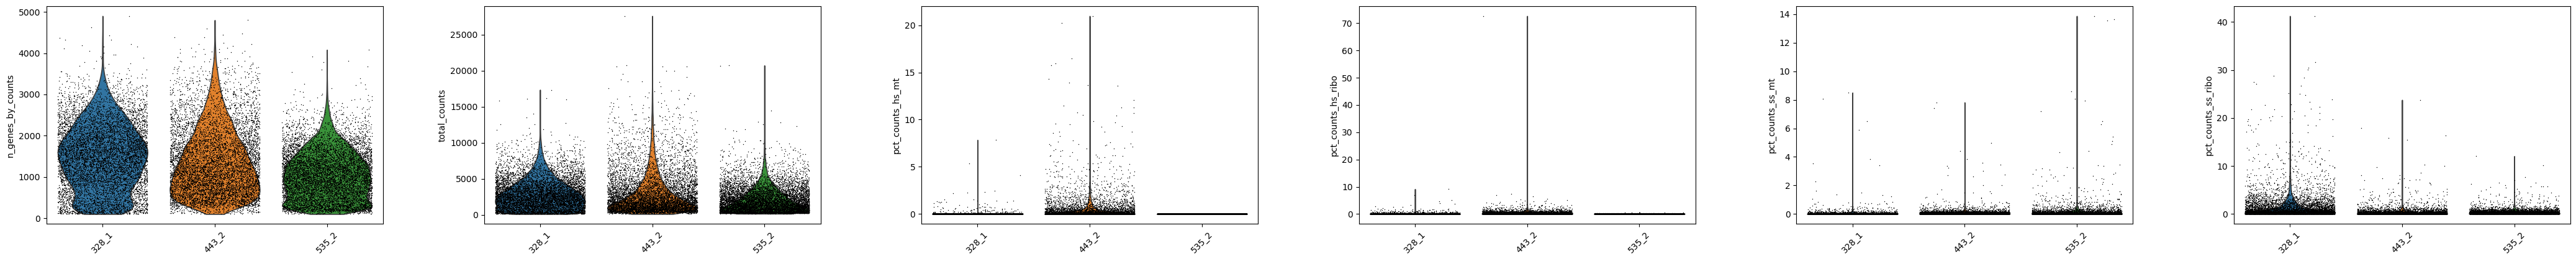

In [4]:
# Correct list of Sus_scrofa mitochondrial genes from your input
sus_scrofa_mt_genes = [
    "ND1", "ND2", "ND3", "ND4", "ND4L", "ND5", "ND6", "CYB", "CO1",
    "CO2", "CO3", "ATP6", "ATP8", "RNR1", "RNR2", "TA", "TC", "TD",
    "TE", "TF", "TG", "TH", "TI", "TK", "TL1", "TL2", "TM", "TN",
    "TP", "TQ", "TR", "TS1", "TS2", "TT", "TV", "TW", "TY"
]

# Prepend the prefix 'Sus_scrofa___' to each gene name
sus_scrofa_mt_genes_prefixed = [f"Sus_scrofa___{gene}" for gene in sus_scrofa_mt_genes]

#######Quality control

# Mitochondrial genes
adata.var["hs_mt"] = adata.var_names.str.startswith("Homo_sapiens_MT-")
# Identify Sus_scrofa MT genes using the provided list
adata.var["ss_mt"] = adata.var_names.isin(sus_scrofa_mt_genes_prefixed)

# Ribosomal genes
adata.var["hs_ribo"] = adata.var_names.str.startswith(("Homo_sapiens_RPS", "Homo_sapiens_RPL"))
adata.var["ss_ribo"] = adata.var_names.str.startswith(("Sus_scrofa___RPS", "Sus_scrofa___RPL"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["hs_mt", "hs_ribo", "ss_mt", "ss_ribo"], inplace=True, log1p=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_hs_mt", "pct_counts_hs_ribo", "pct_counts_ss_mt", "pct_counts_ss_ribo"],
    jitter=0.4,
    multi_panel=True,
    groupby='sample',
    rotation=45
)

# 3. Filter

In [5]:
mt_percent_filter=1

Counter({'535_2': 8300, '443_2': 6421, '328_1': 5568})


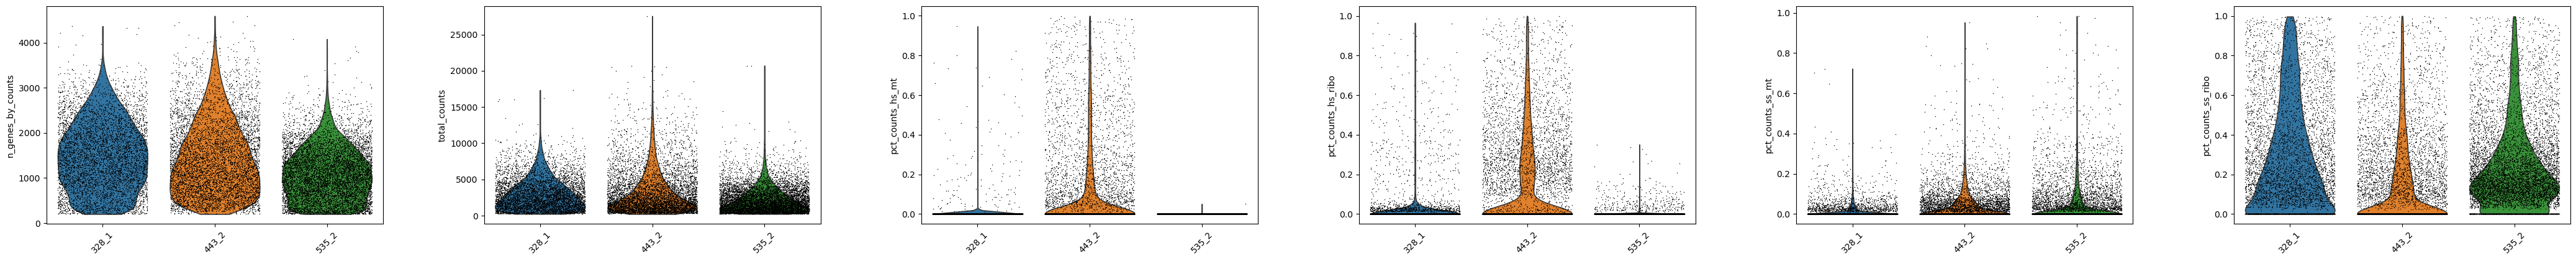

AnnData object with n_obs × n_vars = 20289 × 36545
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'hs_mt', 'ss_mt', 'hs_ribo', 'ss_ribo', 'n_cells_by_counts', 'mean_

In [6]:
#######filter cells with noise genes
adata_filter=adata[
    (adata.obs["total_counts"] < 40000) &
    (adata.obs["n_genes_by_counts"] > 200) &
    (adata.obs["n_genes_by_counts"] < 5000) &
    (adata.obs["pct_counts_hs_mt"] < mt_percent_filter) &
    (adata.obs["pct_counts_hs_ribo"] < 1) &
    (adata.obs["pct_counts_ss_mt"] < mt_percent_filter) &
    (adata.obs["pct_counts_ss_ribo"] < 1) 
].copy()

print(Counter(adata_filter.obs["sample"]))

sc.pl.violin(
    adata_filter,
    ["n_genes_by_counts", "total_counts", "pct_counts_hs_mt", "pct_counts_hs_ribo", "pct_counts_ss_mt", "pct_counts_ss_ribo"],
    jitter=0.4,
    multi_panel=True,
    groupby='sample',
    rotation=45
)



#######again filter number of genes
#######remain 10653 cells x 284888 genes
sc.pp.filter_genes(adata_filter, min_cells=3)
print(adata_filter)

adata_filter.write(output_path+"HTx+control_preprocessed_mtfilter_"+str(mt_percent_filter)+"_ribofilter_10_scrublet015.h5ad")

In [7]:
adata_filter.write(output_path+"Humanxeno_preprocessed_mtfilter_"+str(mt_percent_filter)+"_ribofilter.h5ad")